In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Load raw data
# ============================================================

def load_cel_loureiro(path: str) -> tuple[pd.DataFrame, list[str], list[str]]:
    """
    Load the CEL Loureiro CSV.
    Returns: (df, building_cols, weather_cols)
    """
    df = pd.read_csv(path, parse_dates=["Time"])
    
    # Identify building vs weather columns
    # Buildings are numbered columns or have specific naming
    # Weather columns typically include: Temperature, Humidity, etc.
    non_data_cols = ["Time"]
    
    # Heuristic: weather columns are the last few with non-numeric-looking names
    # or we can identify them by checking which columns have names like 
    # 'Temperature', 'Humidity', 'Pressure', 'Wind', etc.
    weather_keywords = [
        "temp", "humid", "press", "wind", "rain", "radiat", 
        "weather", "precip", "dew"
    ]
    
    weather_cols = []
    building_cols = []
    for c in df.columns:
        if c in non_data_cols:
            continue
        if any(kw in c.lower() for kw in weather_keywords):
            weather_cols.append(c)
        else:
            building_cols.append(c)
    
    print(f"Loaded: {len(df)} rows, {len(building_cols)} buildings, "
          f"{len(weather_cols)} weather columns")
    print(f"Time range: {df['Time'].min()} to {df['Time'].max()}")
    print(f"Building columns (first 5): {building_cols[:5]}")
    print(f"Weather columns: {weather_cols}")
    
    return df, building_cols, weather_cols


# ============================================================
# 2. Aggregate to weekly blocks
# ============================================================

def energy_to_weekly_blocks(
    df: pd.DataFrame,
    building_cols: list[str],
    fill_method: str = "zero",  # "zero", "drop", or "ffill"
) -> tuple[np.ndarray, np.ndarray, int]:
    """
    Aggregate 15-min readings to weekly total consumption per building.
    
    Returns:
        X_np: (B_weeks, n_buildings) float32 — weekly consumption
        weeks: (B_weeks,) — week labels (ISO week or ordinal)
        n_buildings: number of buildings after filtering
    """
    data = df[["Time"] + building_cols].copy()
    
    # Handle NaN
    if fill_method == "zero":
        data[building_cols] = data[building_cols].fillna(0)
    elif fill_method == "ffill":
        data[building_cols] = data[building_cols].ffill().fillna(0)
    elif fill_method == "drop":
        pass  # keep NaN, will become NaN in weekly sums
    
    # Add week identifier (year-week)
    data["year"] = data["Time"].dt.isocalendar().year.astype(int)
    data["week"] = data["Time"].dt.isocalendar().week.astype(int)
    data["year_week"] = data["year"] * 100 + data["week"]
    
    # Sum consumption per week per building
    weekly = data.groupby("year_week")[building_cols].sum()
    
    # Drop buildings with too many zeros or NaN
    nonzero_frac = (weekly > 0).mean(axis=0)
    active_cols = nonzero_frac[nonzero_frac > 0.5].index.tolist()
    print(f"Active buildings (>50% nonzero weeks): {len(active_cols)}/{len(building_cols)}")
    
    weekly = weekly[active_cols]
    
    # Drop partial weeks at start/end (first and last week may be incomplete)
    # Check if first/last weeks have significantly fewer readings
    readings_per_week = data.groupby("year_week")["Time"].count()
    full_week_readings = 7 * 24 * 4  # 672 readings per full week
    partial_threshold = 0.5 * full_week_readings
    full_weeks = readings_per_week[readings_per_week > partial_threshold].index
    weekly = weekly.loc[weekly.index.isin(full_weeks)]
    
    print(f"Full weeks retained: {len(weekly)}")
    
    X_np = weekly.values.astype(np.float32)
    weeks = weekly.index.values
    
    return X_np, weeks, len(active_cols)


# ============================================================
# 3. Deseasonalized excess consumption (recommended approach)
# ============================================================

def energy_to_excess_blocks(
    X_weekly: np.ndarray,
    baseline_quantile: float = 0.50,
    ) -> np.ndarray:
    """
    Loss = max(0, consumption - building's median).
    Captures demand shocks above normal usage, removing the
    seasonal baseline so that winter and summer weeks are comparable.
    
    Args:
        X_weekly: (B, n) weekly consumption
        baseline_quantile: quantile used as baseline (0.5 = median)
    
    Returns:
        X_excess: (B, n) float32 — excess above baseline, clipped at 0
    """
    baseline = np.quantile(X_weekly, baseline_quantile, axis=0, keepdims=True)
    X_excess = np.maximum(X_weekly - baseline, 0).astype(np.float32)
    
    zero_frac = (X_excess == 0).mean()
    nonzero = X_excess[X_excess > 0]
    print(f"Excess above {baseline_quantile:.0%} baseline:")
    print(f"  Zero fraction: {zero_frac:.3f}")
    print(f"  Mean excess per week: {X_excess.sum(axis=1).mean():.1f}")
    print(f"  Nonzero values: mean={nonzero.mean():.2f}, "
          f"median={np.median(nonzero):.2f}, max={nonzero.max():.2f}")
    
    return X_excess

def energy_to_seasonal_excess(
    X_weekly: np.ndarray,
    weeks: np.ndarray,
    window: int = 9,  # rolling window in weeks for seasonal baseline
) -> np.ndarray:
    """
    Loss = max(0, consumption - rolling seasonal baseline).
    Uses a centered rolling median per building to capture 
    seasonal patterns, so the excess represents genuine shocks
    above what's normal for that time of year.
    """
    import pandas as pd
    
    B, n = X_weekly.shape
    baseline = np.zeros_like(X_weekly, dtype=np.float32)
    
    for i in range(n):
        s = pd.Series(X_weekly[:, i])
        # Centered rolling median; min_periods avoids NaN at edges
        baseline[:, i] = s.rolling(
            window=window, center=True, min_periods=window // 2 + 1
        ).median().bfill().ffill().values
    
    X_excess = np.maximum(X_weekly - baseline, 0).astype(np.float32)
    
    zero_frac = (X_excess == 0).mean()
    nonzero = X_excess[X_excess > 0]
    print(f"Seasonal excess (rolling median, window={window}):")
    print(f"  Zero fraction: {zero_frac:.3f}")
    print(f"  Nonzero: mean={nonzero.mean():.2f}, "
          f"median={np.median(nonzero):.2f}, max={nonzero.max():.2f}")
    print(f"  Total per week: mean={X_excess.sum(1).mean():.1f}, "
          f"std={X_excess.sum(1).std():.1f}")
    
    return X_excess


# ============================================================
# 3b. Optional: parametric trigger on excess
# ============================================================

def energy_to_trigger_blocks(
    X_weekly: np.ndarray,
    threshold_quantile: float = 0.90,
    payout: float = 1.0,
) -> tuple[np.ndarray, float]:
    """
    Binary trigger: unit payout if weekly consumption exceeds
    the building's threshold quantile.
    """
    thresholds = np.quantile(X_weekly, threshold_quantile, axis=0)
    X_trigger = payout * (X_weekly > thresholds[None, :]).astype(np.float32)
    
    print(f"Trigger threshold: {threshold_quantile:.0%} quantile per building")
    print(f"Overall trigger rate: {(X_trigger > 0).mean():.3f}")
    
    return X_trigger, threshold_quantile


# ============================================================
# 5. Diagnostics
# ============================================================

def energy_diagnostics(X_np: np.ndarray, weeks: np.ndarray, title: str = ""):
    """Quick diagnostics matching your existing style."""
    B, n = X_np.shape
    
    total_per_week = X_np.sum(axis=1)
    zero_frac = (X_np == 0).mean()
    trigger_rate_per_building = (X_np > 0).mean(axis=0)
    
    print(f"\n[{title}] Shape: ({B}, {n})")
    print(f"  Zero fraction: {zero_frac:.3f}")
    print(f"  Total per week: mean={total_per_week.mean():.1f}, "
          f"std={total_per_week.std():.1f}, "
          f"max={total_per_week.max():.1f}")
    print(f"  Per-building trigger rate: "
          f"mean={trigger_rate_per_building.mean():.3f}, "
          f"min={trigger_rate_per_building.min():.3f}, "
          f"max={trigger_rate_per_building.max():.3f}")
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    axes[0, 0].plot(total_per_week)
    axes[0, 0].set_title("Total consumption per week")
    axes[0, 0].set_xlabel("Week index")
    
    axes[0, 1].hist(trigger_rate_per_building, bins=30)
    axes[0, 1].set_title("Trigger rate distribution across buildings")
    axes[0, 1].set_xlabel("Trigger rate")
    
    axes[1, 0].imshow(X_np.T, aspect="auto", interpolation="none")
    axes[1, 0].set_title("Loss matrix (buildings × weeks)")
    axes[1, 0].set_xlabel("Week index")
    axes[1, 0].set_ylabel("Building")
    
    axes[1, 1].hist(X_np[X_np > 0].flatten(), bins=50)
    axes[1, 1].set_title("Distribution of nonzero losses")
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

Loaded: 46608 rows, 172 buildings, 0 weather columns
Time range: 2022-05-05 12:00:00 to 2023-09-02 23:45:00
Building columns (first 5): ['Energy_Meter_1', 'Energy_Meter_2', 'Energy_Meter_3', 'Energy_Meter_4', 'Energy_Meter_5']
Weather columns: []
Active buildings (>50% nonzero weeks): 153/172
Full weeks retained: 69

[Raw weekly consumption] Shape: (69, 153)
  Zero fraction: 0.070
  Total per week: mean=7722.5, std=2402.4, max=11513.5
  Per-building trigger rate: mean=0.930, min=0.507, max=1.000


/var/folders/4y/gyqs69nx26n_jdyh53h9z9z40000gn/T/ipykernel_40861/1148715589.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["year"] = data["Time"].dt.isocalendar().year.astype(int)
/var/folders/4y/gyqs69nx26n_jdyh53h9z9z40000gn/T/ipykernel_40861/1148715589.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["week"] = data["Time"].dt.isocalendar().week.astype(int)
/var/folders/4y/gyqs69nx26n_jdyh53h9z9z40000gn/T/ipykernel_40861/1148715589.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually 

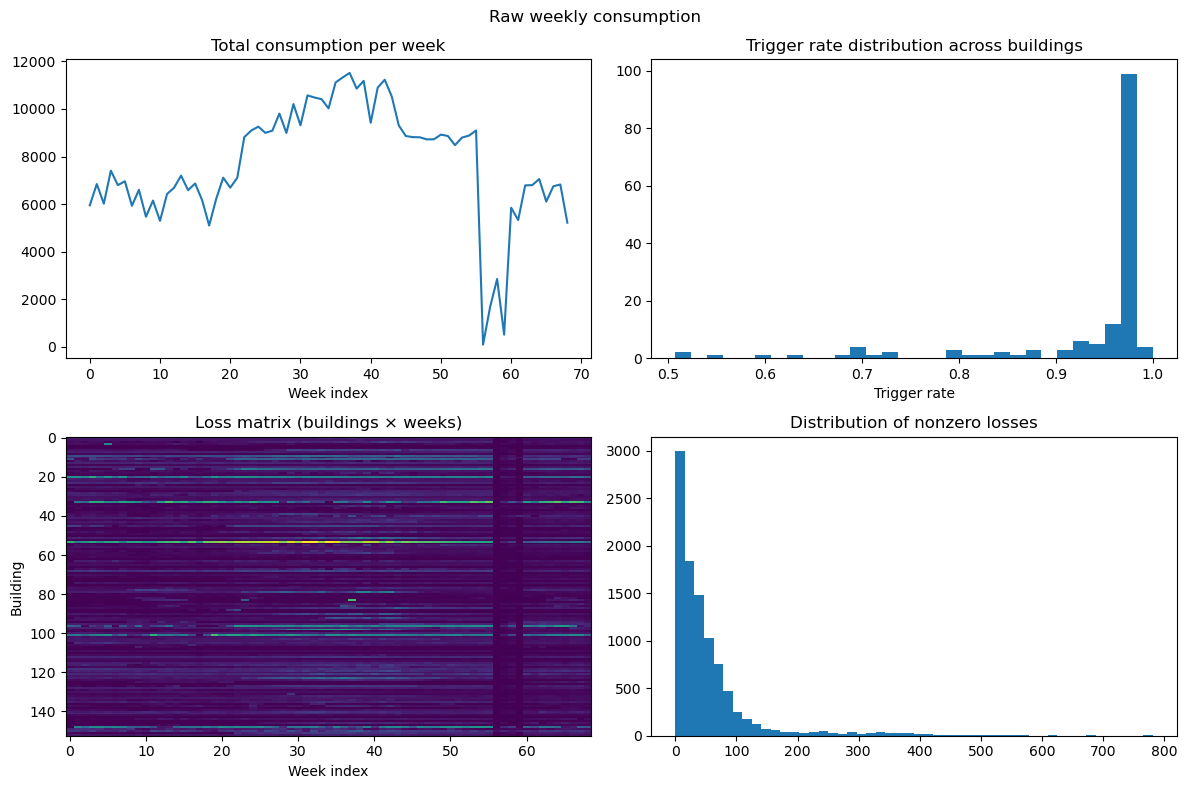

Seasonal excess (rolling median, window=9):
  Zero fraction: 0.577
  Nonzero: mean=9.24, median=3.74, max=543.35
  Total per week: mean=598.1, std=359.2

[Excess above median] Shape: (69, 153)
  Zero fraction: 0.577
  Total per week: mean=598.1, std=359.2, max=1619.6
  Per-building trigger rate: mean=0.423, min=0.217, max=0.478


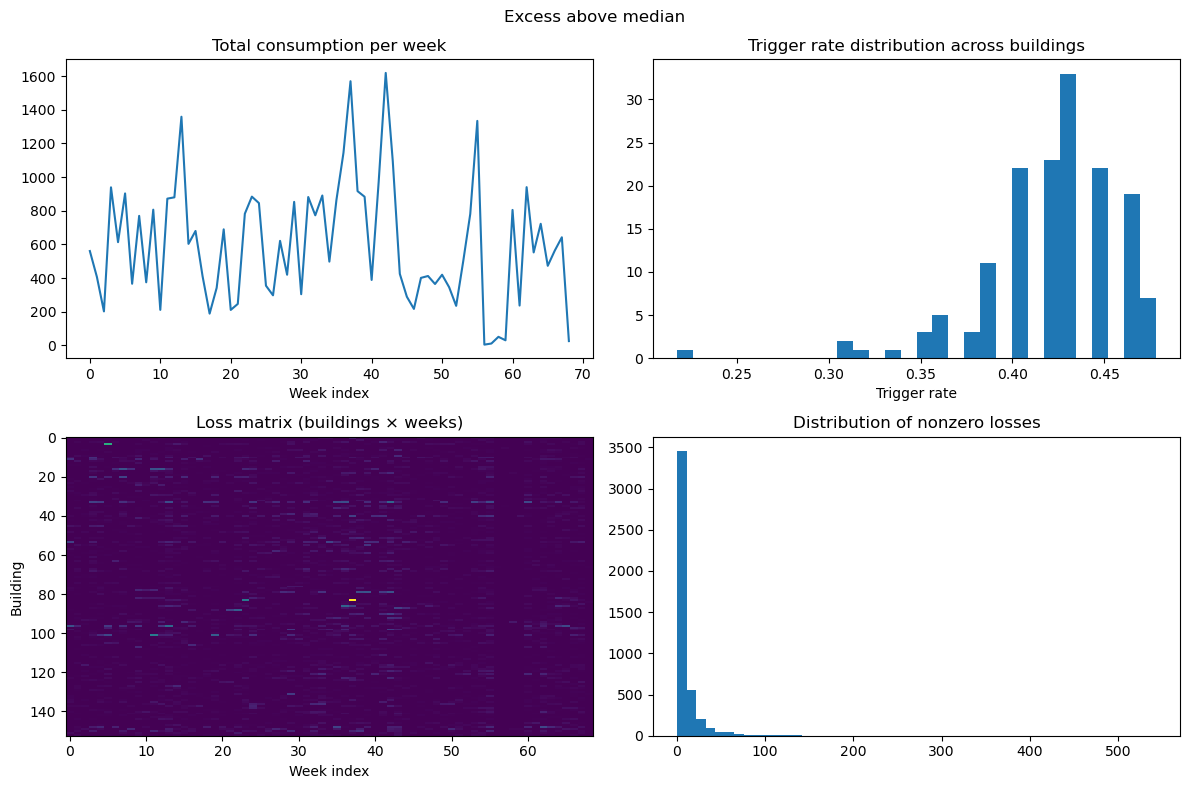

=== Validity-first backtest (updated) ===
Pooling: global-uniform
Mode: random | Splits: 50 | nTest=5 | nC=35
Nominal coverage: 0.900
PASS rate: 1.000

Split-level mean coverage across peers (not theorem-aligned, but intuitive):
  candidate : mean=0.914, std=0.126
  operational: mean=0.914, std=0.126
  identity  : mean=0.914, std=0.031

Worst-peer shortfall from nominal (theorem-aligned empirical):
  candidate   : worst=0.888 (shortfall=0.012), p05=0.900 (shortfall=0.000)
  operational : worst=0.888 (shortfall=0.012), p05=0.900 (shortfall=0.000)
  identity    : worst=0.852 (shortfall=0.048), p05=0.884 (shortfall=0.016)

Certified cap efficiency (lower is better):
  mean <w,c0> (identity)     : 16.3 ± 1.04
  mean <w,c*> (candidate)    : 8.03 ± 1.16
  mean <w,c_op> (operational): 8.03 ± 1.16
  AggCapRatio candidate      : 0.492 ± 0.058
  AggCapRatio operational    : 0.492 ± 0.058

Additional certified utility metrics (lower ratios are better):
  Top10 cap ratio (candidate)   : 0.180 ± 0.

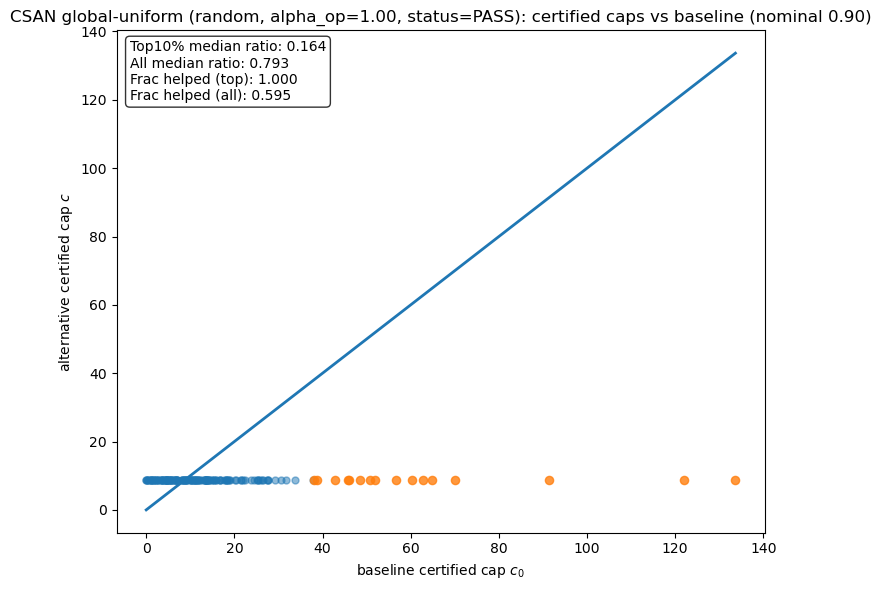

=== Validity-first backtest (updated) ===
Pooling: global-uniform
Mode: time | Splits: 5 | nTest=5 | nC=35
Nominal coverage: 0.900
PASS rate: 1.000

Split-level mean coverage across peers (not theorem-aligned, but intuitive):
  candidate : mean=0.999, std=0.001
  operational: mean=0.999, std=0.001
  identity  : mean=0.912, std=0.011

Worst-peer shortfall from nominal (theorem-aligned empirical):
  candidate   : worst=0.880 (shortfall=0.020), p05=1.000 (shortfall=0.000)
  operational : worst=0.880 (shortfall=0.020), p05=1.000 (shortfall=0.000)
  identity    : worst=0.400 (shortfall=0.500), p05=0.608 (shortfall=0.292)

Certified cap efficiency (lower is better):
  mean <w,c0> (identity)     : 16.6 ± 0.166
  mean <w,c*> (candidate)    : 8.8 ± 0.00118
  mean <w,c_op> (operational): 8.8 ± 0.00118
  AggCapRatio candidate      : 0.530 ± 0.005
  AggCapRatio operational    : 0.530 ± 0.005

Additional certified utility metrics (lower ratios are better):
  Top10 cap ratio (candidate)   : 0.169 ± 

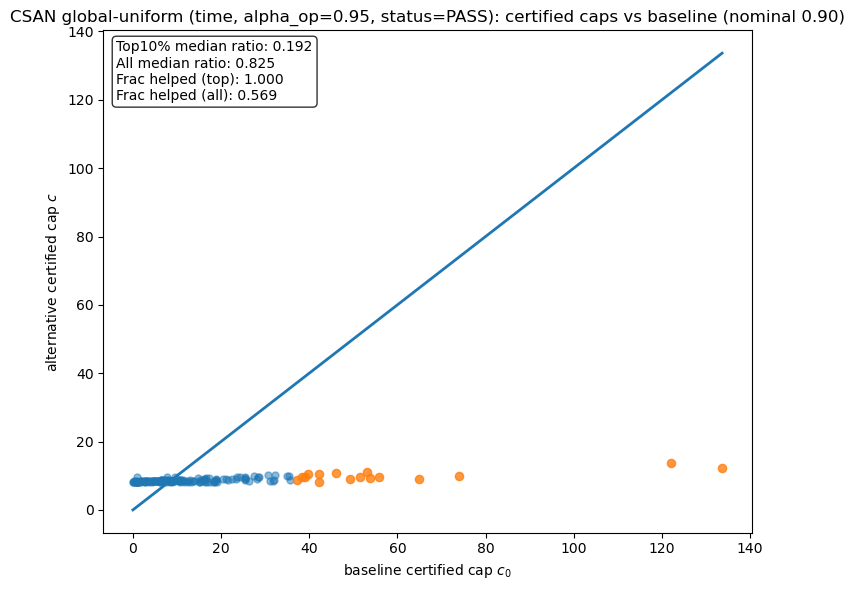

% Random splits (Energy cooperative)
Global & 1.00 & 0.93\tiny$\pm$0.10 & 0.914 (0.900) & 0.492\tiny$\pm$0.058 & 0.180\tiny$\pm$0.079 \\
Identity & -- & 0 & 0.914 (0.884) & -- & -- \\

% Time splits (Energy cooperative)
Global & 1.00 & 0.95\tiny$\pm$0.00 & 0.999 (1.000) & 0.530\tiny$\pm$0.005 & 0.169\tiny$\pm$0.002 \\
Identity & -- & 0 & 0.912 (0.608) & -- & -- \\


In [2]:
# ============================================================
# 6. Full pipeline: load → preprocess → run backtest
# ============================================================

# --- Step 1: Load ---
path = "LoureiroDataset/loureiro_energy.csv"  # UPDATE THIS
df, building_cols, weather_cols = load_cel_loureiro(path)

# --- Step 2: Weekly blocks ---
X_weekly, weeks, n = energy_to_weekly_blocks(df, building_cols)

# --- Step 3: Diagnostics on raw data (check seasonality) ---
energy_diagnostics(X_weekly, weeks, title="Raw weekly consumption")

# --- Step 4: Deseasonalize via excess above median ---
# X_np = energy_to_excess_blocks(X_weekly, baseline_quantile=0.50)
X_np = energy_to_seasonal_excess(X_weekly, weeks)
years = weeks  # block labels (your pipeline just needs unique IDs)

# --- Step 5: Diagnostics on excess data ---
energy_diagnostics(X_np, years, title="Excess above median")

# --- Step 6: Run backtest ---
from csan import (
    validity_first_backtest, print_latex_row, print_latex_identity_row
)

delta, eta, eps = 0.10, 0.0, 0.2

# Random splits (theorem-aligned)
bt_random = validity_first_backtest(
    X_np=X_np, years=years,
    delta=delta, eta=eta, eps=eps,
    alphas=np.linspace(0, 1, 21, dtype=np.float32),
    nT=15, nV=10, nC=35, nTest=5,
    split_mode="random", n_splits=50,
    seed=0, make_plots=False,
    relief_scatter=True,
    W_local=None,  # global pooling
)

# Time-ordered splits (robustness diagnostic)
bt_time = validity_first_backtest(
    X_np=X_np, years=years,
    delta=delta, eta=eta, eps=eps,
    alphas=np.linspace(0, 1, 21, dtype=np.float32),
    nT=15, nV=10, nC=35, nTest=5,
    split_mode="time",
    seed=0, make_plots=False,
    relief_scatter=True,
    W_local=None,  # global pooling
)

# --- Step 7: Print LaTeX tables ---
print("% Random splits (Energy cooperative)")
print_latex_row(bt_random, "Global")
print_latex_identity_row(bt_random)

print()
print("% Time splits (Energy cooperative)")
print_latex_row(bt_time, "Global")
print_latex_identity_row(bt_time)

In [3]:
for eps_val in [0.01, 0.05, 0.10, 0.20]:
    bt = validity_first_backtest(
        X_np=X_np, years=years,
        delta=delta, eta=eta, eps=eps_val,
        alphas=np.linspace(0, 1, 21, dtype=np.float32),
        nT=15, nV=10, nC=35, nTest=5,
        split_mode="random", n_splits=50,
        seed=0, make_plots=False, W_local=None,
    )
    s = bt["peer_cov_summary_operational"]
    pass_rate = float(np.mean([st == "PASS" for st in bt["status"]]))
    agg = np.nanmean(bt["cap_ratio_operational"])
    top = np.nanmean(bt["top10_ratio_operational"])
    alp = np.mean(bt["alpha_op"])
    print(f"eps={eps_val:.2f}: PASS={pass_rate:.2f} alpha={alp:.2f} "
          f"Cov={s['mean']:.3f}({s['p05']:.3f}) "
          f"AggCap={agg:.3f} Top10={top:.3f}")


=== Validity-first backtest (updated) ===
Pooling: global-uniform
Mode: random | Splits: 50 | nTest=5 | nC=35
Nominal coverage: 0.900
PASS rate: 1.000

Split-level mean coverage across peers (not theorem-aligned, but intuitive):
  candidate : mean=0.914, std=0.034
  operational: mean=0.914, std=0.034
  identity  : mean=0.914, std=0.031

Worst-peer shortfall from nominal (theorem-aligned empirical):
  candidate   : worst=0.852 (shortfall=0.048), p05=0.884 (shortfall=0.016)
  operational : worst=0.852 (shortfall=0.048), p05=0.884 (shortfall=0.016)
  identity    : worst=0.852 (shortfall=0.048), p05=0.884 (shortfall=0.016)

Certified cap efficiency (lower is better):
  mean <w,c0> (identity)     : 16.3 ± 1.04
  mean <w,c*> (candidate)    : 15.7 ± 1.02
  mean <w,c_op> (operational): 15.7 ± 1.02
  AggCapRatio candidate      : 0.965 ± 0.012
  AggCapRatio operational    : 0.965 ± 0.012

Additional certified utility metrics (lower ratios are better):
  Top10 cap ratio (candidate)   : 0.953 ± 0.

In [4]:
bt_random_tight = validity_first_backtest(
    X_np=X_np, years=years,
    delta=delta, eta=eta, eps=0.05,
    alphas=np.linspace(0, 1, 21, dtype=np.float32),
    nT=15, nV=10, nC=35, nTest=5,
    split_mode="random", n_splits=50,
    seed=0, make_plots=False, W_local=None,
)

print("% Energy cooperative, random splits")
print_latex_row(bt_random_tight, r"Global ($\varepsilon\!=\!0.05$)")
print_latex_row(bt_random, r"Global ($\varepsilon\!=\!0.20$)")
print_latex_identity_row(bt_random)

=== Validity-first backtest (updated) ===
Pooling: global-uniform
Mode: random | Splits: 50 | nTest=5 | nC=35
Nominal coverage: 0.900
PASS rate: 1.000

Split-level mean coverage across peers (not theorem-aligned, but intuitive):
  candidate : mean=0.914, std=0.047
  operational: mean=0.914, std=0.047
  identity  : mean=0.914, std=0.031

Worst-peer shortfall from nominal (theorem-aligned empirical):
  candidate   : worst=0.852 (shortfall=0.048), p05=0.886 (shortfall=0.014)
  operational : worst=0.852 (shortfall=0.048), p05=0.886 (shortfall=0.014)
  identity    : worst=0.852 (shortfall=0.048), p05=0.884 (shortfall=0.016)

Certified cap efficiency (lower is better):
  mean <w,c0> (identity)     : 16.3 ± 1.04
  mean <w,c*> (candidate)    : 12.9 ± 1.11
  mean <w,c_op> (operational): 12.9 ± 1.11
  AggCapRatio candidate      : 0.795 ± 0.048
  AggCapRatio operational    : 0.795 ± 0.048

Additional certified utility metrics (lower ratios are better):
  Top10 cap ratio (candidate)   : 0.719 ± 0.

row sums: 0.9999999 1.0 1.0
col sums: 0.9999995 1.0 1.0000004
min entry: 0.004399481 max entry: 0.009514174
[split 0] VO objective: J(I)=1.938e+04 J(U)=704.8 J(A_bar)=704.8  min_J_over_alphas=704.8 at alpha=1.00
row sums: 0.9999999 1.0 1.0000001
col sums: 0.9999995 1.0 1.0000004
min entry: 0.004392595 max entry: 0.009596318
row sums: 0.99999994 1.0 1.0000001
col sums: 0.9999995 1.0 1.0000005
min entry: 0.004279629 max entry: 0.009325761
row sums: 0.99999994 1.0 1.0000001
col sums: 0.9999996 1.0 1.0000005
min entry: 0.0043942668 max entry: 0.00927777
row sums: 0.99999994 1.0 1.0000001
col sums: 0.9999996 1.0 1.0000006
min entry: 0.0044782683 max entry: 0.0093633635
row sums: 0.99999994 1.0 1.0000001
col sums: 0.9999995 1.0 1.0000004
min entry: 0.0043308907 max entry: 0.009902811
row sums: 0.9999999 1.0 1.0000001
col sums: 0.9999996 1.0 1.0000005
min entry: 0.0043005897 max entry: 0.009505474
row sums: 0.9999999 1.0 1.0000001
col sums: 0.9999996 1.0 1.0000005
min entry: 0.004371401 max e

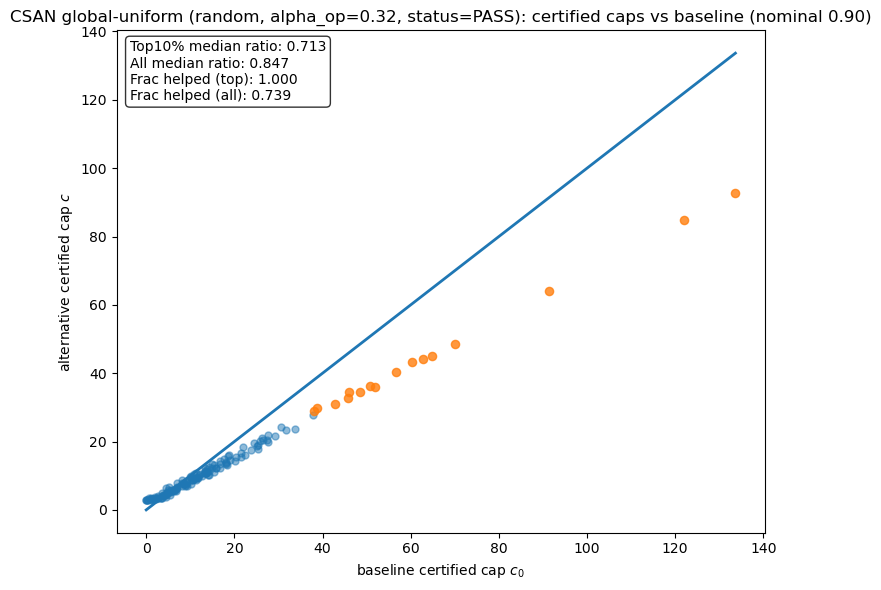

row sums: 0.9999999 1.0 1.0
col sums: 0.9999995 1.0 1.0000004
min entry: 0.004399481 max entry: 0.009514174
[split 0] VO objective: J(I)=1.938e+04 J(U)=704.8 J(A_bar)=704.8  min_J_over_alphas=704.8 at alpha=1.00
row sums: 0.9999999 1.0 1.0000001
col sums: 0.9999995 1.0 1.0000004
min entry: 0.004392595 max entry: 0.009596318
row sums: 0.99999994 1.0 1.0000001
col sums: 0.9999995 1.0 1.0000005
min entry: 0.004279629 max entry: 0.009325761
row sums: 0.99999994 1.0 1.0000001
col sums: 0.9999996 1.0 1.0000005
min entry: 0.0043942668 max entry: 0.00927777
row sums: 0.99999994 1.0 1.0000001
col sums: 0.9999996 1.0 1.0000006
min entry: 0.0044782683 max entry: 0.0093633635
row sums: 0.99999994 1.0 1.0000001
col sums: 0.9999995 1.0 1.0000004
min entry: 0.0043308907 max entry: 0.009902811
row sums: 0.9999999 1.0 1.0000001
col sums: 0.9999996 1.0 1.0000005
min entry: 0.0043005897 max entry: 0.009505474
row sums: 0.9999999 1.0 1.0000001
col sums: 0.9999996 1.0 1.0000005
min entry: 0.004371401 max e

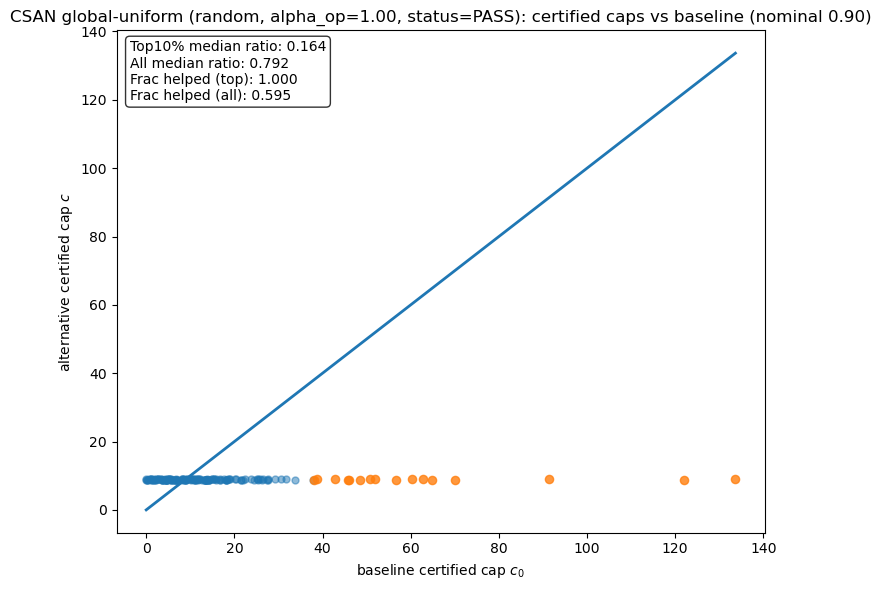

VO-DS ($\varepsilon\!=\!0.05$) & 1.00 & 0.32\tiny$\pm$0.08 & 0.914 (0.884) & 0.786\tiny$\pm$0.048 & 0.708\tiny$\pm$0.070 \\
VO-DS ($\varepsilon\!=\!0.20$) & 1.00 & 0.94\tiny$\pm$0.09 & 0.914 (0.900) & 0.490\tiny$\pm$0.057 & 0.175\tiny$\pm$0.075 \\


In [5]:
bt_VO_DS_eps005 = validity_first_backtest(
    X_np=X_np, years=years,
    delta=delta, eta=eta, eps=0.05,
    alphas=np.linspace(0,1,51, dtype=np.float32),
    nT=15, nV=10, nC=35, nTest=5,
    split_mode="random", n_splits=50,
    make_plots=False,
    use_vo_Abar=True,
    relief_scatter=True,
    relief_scatter_pick = "first_pass",  # "first_pass" | "median_top10" | "best_top10"
)

bt_VO_DS_eps02 = validity_first_backtest(
    X_np=X_np, years=years,
    delta=delta, eta=eta, eps=0.2,
    alphas=np.linspace(0,1,51, dtype=np.float32),
    nT=15, nV=10, nC=35, nTest=5,
    split_mode="random", n_splits=50,
    make_plots=False,
    use_vo_Abar=True,
    relief_scatter=True,
    relief_scatter_pick = "first_pass",  # "first_pass" | "median_top10" | "best_top10"
)

print_latex_row(bt_VO_DS_eps005, r"VO-DS ($\varepsilon\!=\!0.05$)")
print_latex_row(bt_VO_DS_eps02, r"VO-DS ($\varepsilon\!=\!0.20$)")



# Dependence diagnostics: Energy cooperative

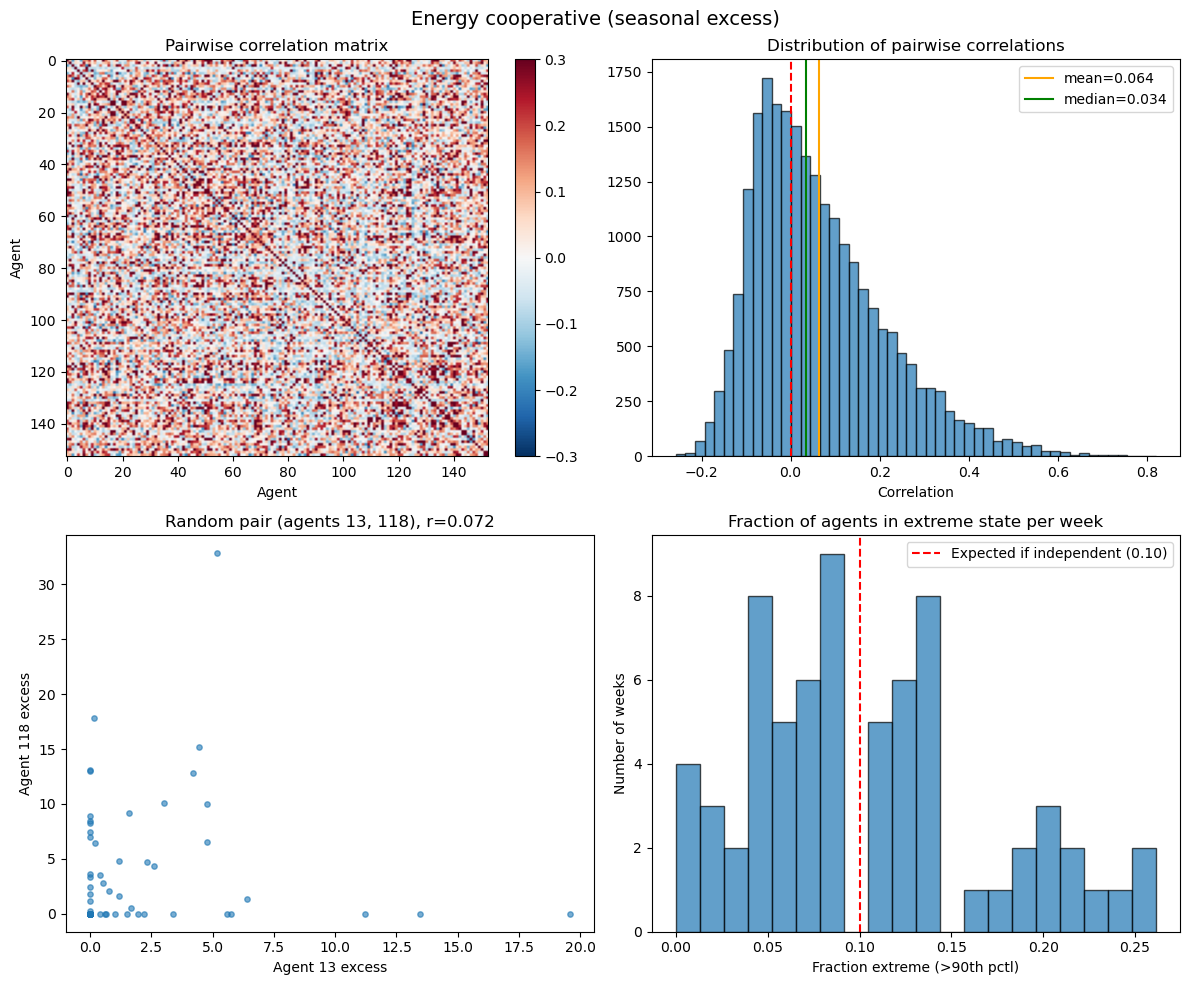


[Energy cooperative (seasonal excess)] Dependence summary:
  Pairwise correlations: mean=0.0635, median=0.0338, p95=0.3499
  Fraction extreme per week: mean=0.101, std=0.065, max=0.261
  If independent, std would be ~0.0243


In [6]:


# --- Pairwise correlation matrix ---
def plot_dependence_diagnostics(X_np, title=""):
    B, n = X_np.shape
    
    # Correlation matrix of losses across agents
    # Use only nonzero-variance columns
    std = X_np.std(axis=0)
    active = std > 1e-10
    X_active = X_np[:, active]
    
    corr = np.corrcoef(X_active.T)  # (n_active, n_active)
    
    # Extract off-diagonal correlations
    mask = ~np.eye(corr.shape[0], dtype=bool)
    offdiag = corr[mask]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # (a) Correlation matrix heatmap
    im = axes[0, 0].imshow(corr, aspect="auto", cmap="RdBu_r", 
                            vmin=-0.3, vmax=0.3)
    axes[0, 0].set_title("Pairwise correlation matrix")
    axes[0, 0].set_xlabel("Agent")
    axes[0, 0].set_ylabel("Agent")
    plt.colorbar(im, ax=axes[0, 0])
    
    # (b) Distribution of off-diagonal correlations
    axes[0, 1].hist(offdiag, bins=50, edgecolor="black", alpha=0.7)
    axes[0, 1].axvline(0, color="red", linestyle="--")
    axes[0, 1].axvline(offdiag.mean(), color="orange", linestyle="-",
                        label=f"mean={offdiag.mean():.3f}")
    axes[0, 1].axvline(np.median(offdiag), color="green", linestyle="-",
                        label=f"median={np.median(offdiag):.3f}")
    axes[0, 1].set_title("Distribution of pairwise correlations")
    axes[0, 1].set_xlabel("Correlation")
    axes[0, 1].legend()
    
    # (c) Scatter: random pair of agents
    rng = np.random.default_rng(42)
    i, j = rng.choice(X_active.shape[1], size=2, replace=False)
    r_ij = np.corrcoef(X_active[:, i], X_active[:, j])[0, 1]
    axes[1, 0].scatter(X_active[:, i], X_active[:, j], s=15, alpha=0.6)
    axes[1, 0].set_title(f"Random pair (agents {i}, {j}), r={r_ij:.3f}")
    axes[1, 0].set_xlabel(f"Agent {i} excess")
    axes[1, 0].set_ylabel(f"Agent {j} excess")
    
    # (d) Co-exceedance: when agent i has extreme loss, 
    #     what fraction of other agents also have extreme loss?
    threshold = np.quantile(X_active, 0.90, axis=0)  # per-agent 90th pctl
    extreme = (X_active > threshold[None, :])  # (B, n) bool
    
    # For each week, fraction of agents in extreme state
    frac_extreme = extreme.mean(axis=1)  # (B,)
    
    # If independent, this should be ~0.10 always
    # If dependent, some weeks have many agents extreme simultaneously
    axes[1, 1].hist(frac_extreme, bins=20, edgecolor="black", alpha=0.7)
    axes[1, 1].axvline(0.10, color="red", linestyle="--", 
                        label="Expected if independent (0.10)")
    axes[1, 1].set_title("Fraction of agents in extreme state per week")
    axes[1, 1].set_xlabel("Fraction extreme (>90th pctl)")
    axes[1, 1].set_ylabel("Number of weeks")
    axes[1, 1].legend()
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Summary stats
    print(f"\n[{title}] Dependence summary:")
    print(f"  Pairwise correlations: mean={offdiag.mean():.4f}, "
          f"median={np.median(offdiag):.4f}, "
          f"p95={np.quantile(offdiag, 0.95):.4f}")
    print(f"  Fraction extreme per week: mean={frac_extreme.mean():.3f}, "
          f"std={frac_extreme.std():.3f}, "
          f"max={frac_extreme.max():.3f}")
    print(f"  If independent, std would be ~{np.sqrt(0.1*0.9/X_active.shape[1]):.4f}")


# --- Run on energy cooperative data ---
plot_dependence_diagnostics(X_np, title="Energy cooperative (seasonal excess)")

# --- If you have E-OBS data loaded, compare ---
# plot_dependence_diagnostics(X_np_eobs, title="E-OBS precipitation triggers")